Implement the Q-learning algorithm in Python for a simple 5x5 grid world environment for an agent to reach the bottom-right cell as its goal starting from the top-left position and with action space defined as {up, down, right, left}. Use this implementation to find the optimal policy. 


In [2]:
import numpy as np
import matplotlib.pyplot as plt


In [3]:

grid_size = 5
gamma = 0.1 
alpha = 0.1  
epsilon = 0.1  
num_episodes = 1000

grid = np.full((grid_size, grid_size), -1)  
grid[-1, -1] = 10 


actions = ['up', 'down', 'left', 'right']
q_table = np.zeros((grid_size, grid_size, len(actions)))


def get_next_state(state, action):
    i, j = state
    if action == 'up' and i > 0:
        return (i - 1, j)
    elif action == 'down' and i < grid_size - 1:
        return (i + 1, j)
    elif action == 'left' and j > 0:
        return (i, j - 1)
    elif action == 'right' and j < grid_size - 1:
        return (i, j + 1)
    return state

def get_reward(state):
    return grid[state]


def choose_action(state):
    if np.random.rand() < epsilon:
        return np.random.choice(actions)
    else:
        return actions[np.argmax(q_table[state[0], state[1], :])]


for episode in range(num_episodes):
    state = (0, 0) 
    done = False
    while not done:
        action = choose_action(state)
        next_state = get_next_state(state, action)
        reward = get_reward(next_state)
        action_index = actions.index(action)


        q_table[state[0], state[1], action_index] += alpha * (reward + gamma * np.max(q_table[next_state[0], next_state[1], :]) - q_table[state[0], state[1], action_index])
        
        state = next_state


        if reward == 10:
            done = True



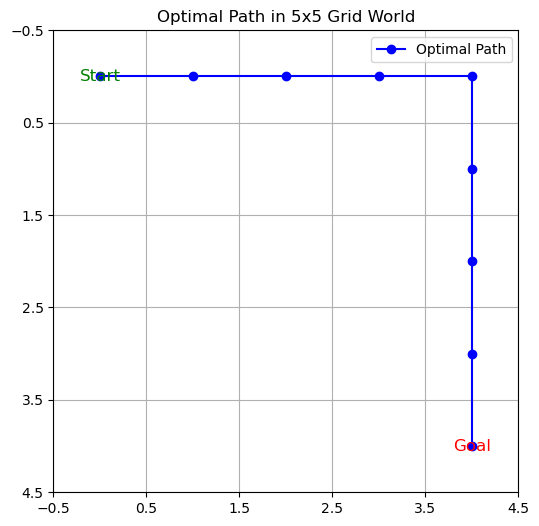

In [13]:
# ...existing code...

# Extract optimal path from (0,0) to (4,4)
state = (0, 0)
optimal_path = [state]
while state != (grid_size - 1, grid_size - 1):
    action_index = np.argmax(q_table[state[0], state[1], :])
    action = actions[action_index]
    next_state = get_next_state(state, action)
    if next_state == state:
        break
    optimal_path.append(next_state)
    state = next_state

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-0.5, grid_size - 0.5)
ax.set_ylim(-0.5, grid_size - 0.5)
ax.set_xticks(np.arange(-0.5, grid_size, 1))
ax.set_yticks(np.arange(-0.5, grid_size, 1))
ax.grid(True)


path_x = [s[1] for s in optimal_path]
path_y = [s[0] for s in optimal_path]
ax.plot(path_x, path_y, marker='o', color='b', label='Optimal Path')


ax.text(0, 0, 'Start', ha='center', va='center', color='green', fontsize=12)
ax.text(grid_size-1, grid_size-1, 'Goal', ha='center', va='center', color='red', fontsize=12)

ax.invert_yaxis()
ax.legend()
plt.title('Optimal Path in 5x5 Grid World')

plt.show()
